<h1 style="width:50px;height:50px;">Setup</h1>

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<h1 style="height:30px; color:blue;">Note :</h1><br>Through each cell some variables are dependent on the above cells so you will need to execute all above cells then the cell itself 

<h1 style="height:60px; color:red;">Task 2.1</h1>

<h1 style="width:100%;height:40px;">Top 10 Nations All time Goals</h1>

Text(0.5, 0, 'Teams')

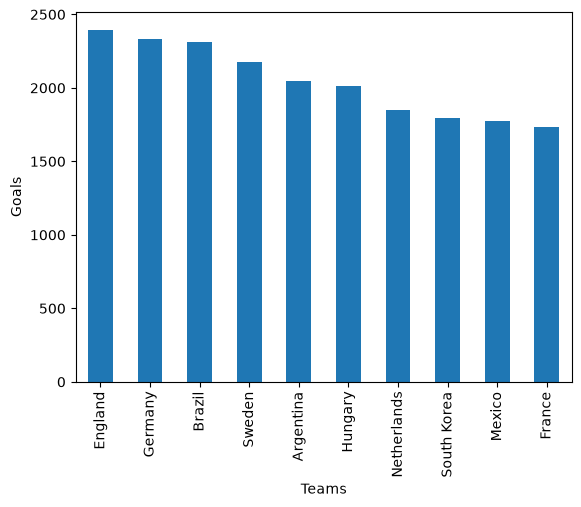

In [26]:
df=pd.read_csv("results.csv")
df=df.dropna()
teams=pd.concat([df["home_team"],df["away_team"]])
goals=pd.concat([df["home_score"],df["away_score"]])
team_goals=pd.DataFrame({"team":teams,"goals":goals})
top_10_nations=team_goals.groupby("team")["goals"].sum().sort_values(ascending=False).head(10)
top_10_nations.plot.bar()
plt.ylabel("Goals")
plt.xlabel("Teams")

<h1 style="width:100%;height:40px;">Top 10 Goalscorers of All time</h1>

Text(0, 0.5, 'Goals')

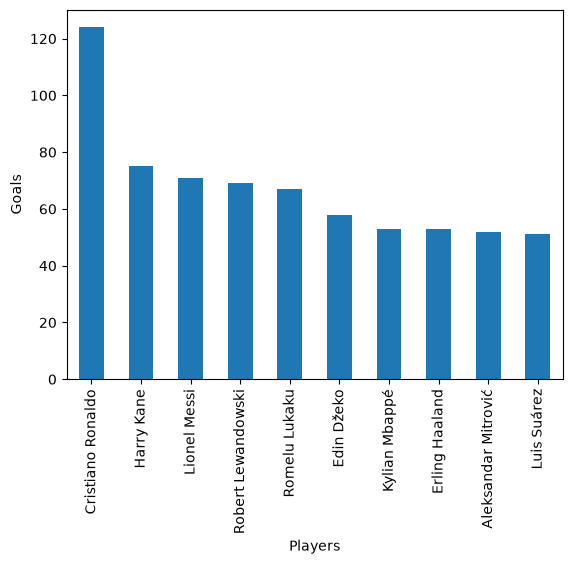

In [27]:
df=pd.read_csv("goalscorers.csv")
df=df.dropna()
scorers=df[df["own_goal"]==False]["scorer"].value_counts().sort_values(ascending=False).head(10)
scorers.plot.bar()
plt.xlabel("Players")
plt.ylabel("Goals")

<h1 style="width:100%;height:50px;">Top 10 Countries with highest average points</h1>

Text(0, 0.5, 'Average Points')

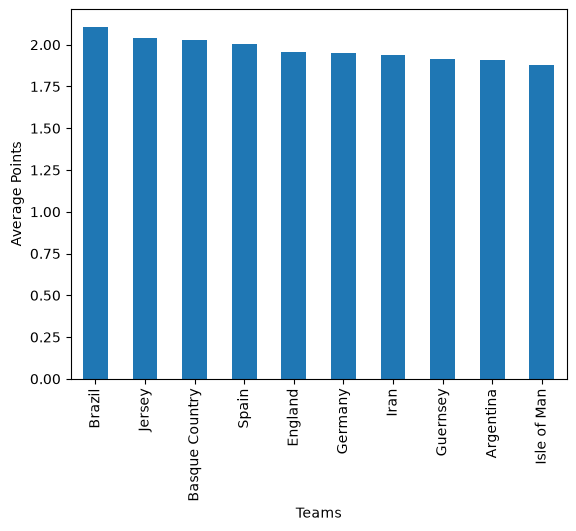

In [28]:
df=pd.read_csv("results.csv")
df=df.dropna()
df["home_points"]=(df["home_score"]>df["away_score"])*3 | (df["home_score"]==df["away_score"]) *1
df["away_points"]=(df["home_score"]<df["away_score"])*3 | (df["home_score"]==df["away_score"])*1
teams=pd.concat([df["home_team"],df["away_team"]])
points=pd.concat([df["home_points"],df["away_points"]]) 
goals=pd.concat([df["home_score"],df["away_score"]])
team_points=pd.DataFrame({"team":teams,"points":points,"goals":goals})
team_points=team_points[team_points["team"].map(team_points["team"].value_counts())>50] #Since value_counts() returns a series length that doesnt match the original one we cant do condition however it's keys and values are exactly what we want to map so we temporarily replace the teams values with their values returned from values_count() and then do our filtering
top_10_avg_pts=team_points.groupby("team")["points"].mean().sort_values(ascending=False).head(10)
top_10_avg_pts.plot.bar()
plt.xlabel("Teams")
plt.ylabel("Average Points")

Text(0, 0.5, 'Average Goals')

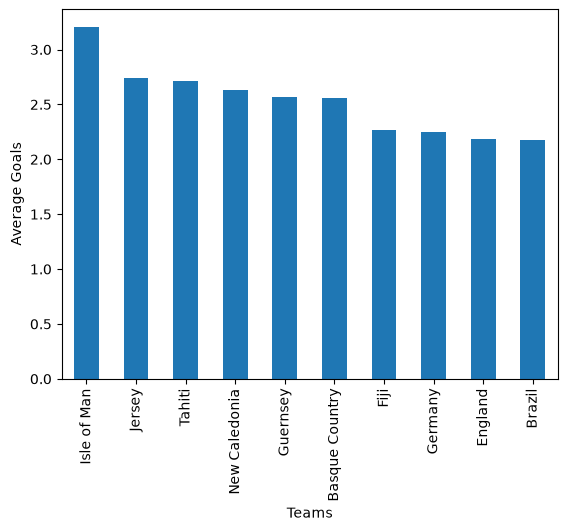

In [29]:
top_10_avg_goals=team_points.groupby("team")["goals"].mean().sort_values(ascending=False).head(10)
top_10_avg_goals.plot.bar()
plt.xlabel("Teams")
plt.ylabel("Average Goals")

<h1 style="width:100%;height:50px">Most shootouts in decades</h1>

Text(0, 0.5, 'Shootouts Played')

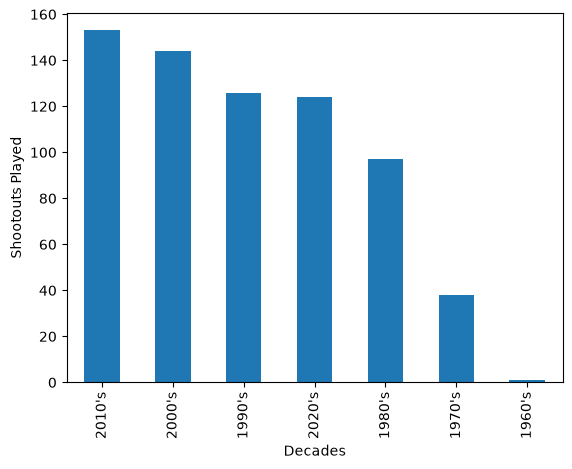

In [30]:
shootouts=pd.read_csv("shootouts.csv")
def decade_map(date):
    year=date.split("-")[0]
    return str(year[0:3])+"0's"
shootouts["decade"]=shootouts["date"].map(decade_map)
most_decade_shootouts=shootouts["decade"].value_counts().sort_values(ascending=False).head(10)
most_decade_shootouts.plot.bar()
plt.xlabel("Decades")
plt.ylabel("Shootouts Played")

<h1 style="height:50px;">Most Shootouts by Tournaments</h1> 

Text(0, 0.5, 'Penalty Shootouts')

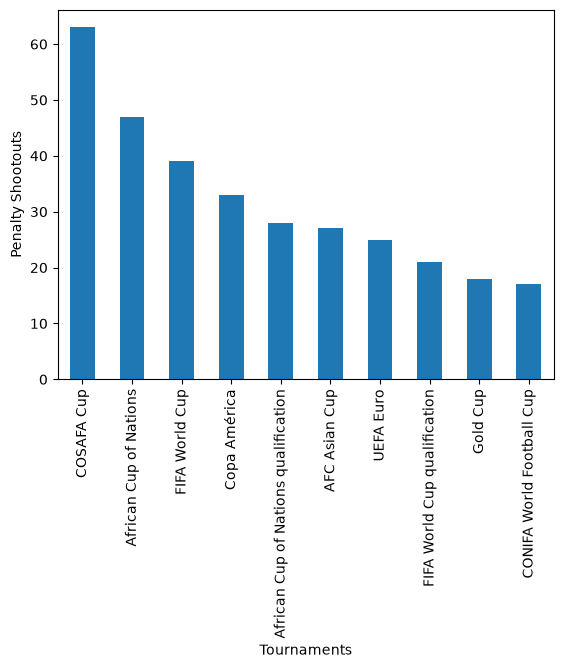

In [31]:
shootouts=pd.read_csv("shootouts.csv")
results=pd.read_csv("results.csv")
conjoined_table=results.merge(shootouts[["date","home_team","away_team"]])
def tournament_map(tournament):
    if tournament=="Friendly":
        return False
    return True
conjoined_table["is_tournament"]=conjoined_table["tournament"].map(tournament_map)
conjoined_table=conjoined_table[conjoined_table["is_tournament"]==True]
conjoined_table["tournament"].value_counts().head(10).plot.bar()
plt.xlabel("Tournaments")
plt.ylabel("Penalty Shootouts")

<h1 style="height:50px;">Teams that scored first and lost</h1>

Text(0, 0.5, 'Losses')

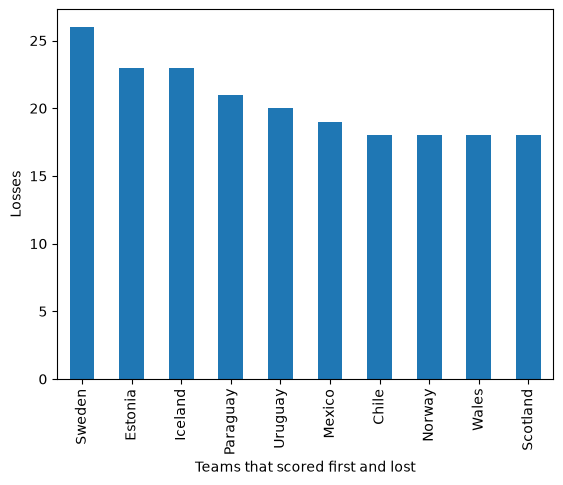

In [32]:
goalscores=pd.read_csv("goalscorers.csv")
results=pd.read_csv("results.csv")  
results=results.merge(goalscores)
results["first_score"]=~ (results.duplicated(subset=["date","home_team","away_team"]))
results=results[results["first_score"]==True]
results=results[  ((results["team"]==results["home_team"])&(results["home_score"]<results["away_score"])) | ((results["team"]==results["away_team"])&(results["away_score"]<results["home_score"]))]  
scored_yet_lost=results["team"].value_counts().head(10)
scored_yet_lost.plot.bar()
plt.xlabel("Teams that scored first and lost")
plt.ylabel("Losses")

<h1 style="height:50px;">Draw rates,Goals per match, and Winning rates changes by each decade</h1>

0         True
1        False
2        False
3         True
4        False
         ...  
49515    False
49516    False
49517    False
49518    False
49519    False
Name: draw, Length: 49520, dtype: bool


<Axes: xlabel='decade'>

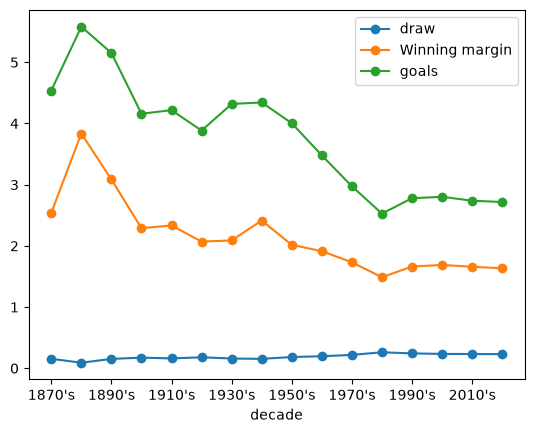

In [ ]:
results=pd.read_csv("results.csv")
def decade_map(date):
    year=date.split("-")[0]
    return str(year[0:3])+"0's"
results["decade"]=results["date"].map(decade_map)
results["draw"]=results["home_score"]==results["away_score"]
results["Winning margin"]=abs(results["home_score"]-results["away_score"])
results["goals"]=results["home_score"]+results["away_score"]
results.groupby("decade")[["draw","Winning margin","goals"]].mean().plot(marker="o")


<h1 style="height:60px; color:red">Task 2.2</h1>

<h1 style="height:50px">Cleaning data</h1>

In [34]:
players=pd.read_csv("kl.csv",encoding="cp1252")
def value_mapping(value):
   value=str(value).split("€")[1]
   if value.endswith("M"):
      return float(value[0:-1])*(10**6)
   elif value.endswith("K"):
      return float(value[0:-1])*(10**3)
   return value
players["Value"]=players["Value"].map(value_mapping).astype(int)
def position_mapping(position):
    return position.split("+")[0]

for i in players.columns:
    if players[i].dtypes=="str" and len(players[players[i].str.contains("+",regex=False)][i])>0: # the mapping returns Null if we choose a feature that doesnt have a +
      players[i]=players[players[i].str.contains("+",regex=False)][i].map(position_mapping).astype(int) #Take the attribute and ignore the potential rating


def weight_mapping(weight):
   return float(str(weight).split("lbs")[0])/2.205
players["Weight"]=players["Weight"].map(weight_mapping).astype(float)

def height_mapping(height):
   foot,inches=str(height).split("'")
   return (float(foot)*12 + float(inches))*0.0254

players["Height"]=players[players["Height"].notna()]["Height"].map(height_mapping).astype(float)


players["Age"]=players["Age"].fillna(36) #Only one player's age is missing
important_attributes=[ 'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
       'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
       'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
       'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots',
       'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
       'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving',
       'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes','Value']  
for i in important_attributes:
   players[i]=players[i].fillna(players[i].mean()) #Fill null values with their feature mean
numerical_data=pd.DataFrame()
numerical_data=players[important_attributes]


<h1 style="height:50px">PCA analysis of the first two components</h1>

Text(0, 0.5, 'Second PCA Component')

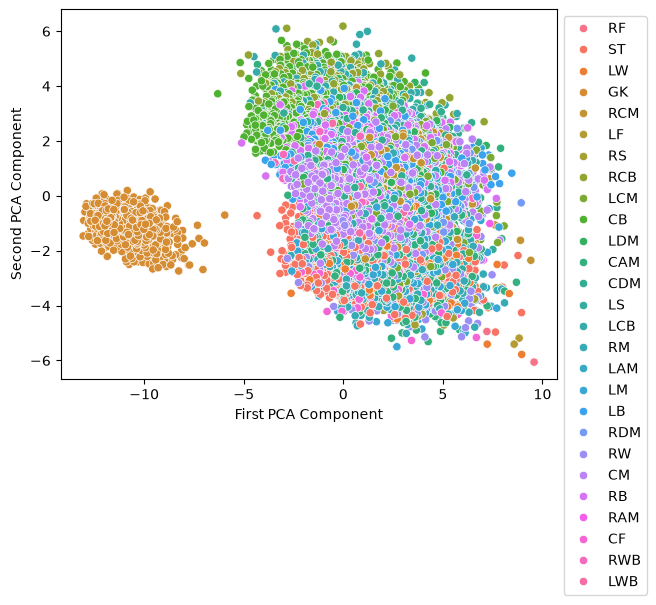

In [35]:
mean_vector=np.mean(numerical_data,axis=0)
std_vector=np.std(numerical_data,axis=0)
standarized_numerical_data=(numerical_data-mean_vector)/std_vector

covariance_mat=np.cov(standarized_numerical_data.to_numpy(),rowvar=False) #rowvar means each row is a variable but they arent variables they are samples so set to false
eigenvalues,eigenvectors=np.linalg.eig(covariance_mat)
eigenvalues=eigenvalues.real
eigenvectors=eigenvectors.real
sorted_eigenvalues_indices=list(np.argsort(eigenvalues,descending=True))
sorted_eigenvalues=np.sort(eigenvalues,descending=True)
sorted_eigenvectors=eigenvectors.T[sorted_eigenvalues_indices,:]
player_scores=np.dot(standarized_numerical_data,sorted_eigenvectors.T)
sns.scatterplot(x=player_scores[:,0],y=player_scores[:,1],hue=players["Position"])
plt.legend(bbox_to_anchor=(1,1))
plt.xlabel("First PCA Component")
plt.ylabel("Second PCA Component")


This is the score of Footballer players classified by their position on the first PCA Components
Let's see what these PCA Components represent 

In [36]:
original_vs_PCA=pd.DataFrame([sorted_eigenvectors[0],sorted_eigenvectors[1]],columns=important_attributes)
print(original_vs_PCA)

   Crossing  Finishing  HeadingAccuracy  ShortPassing   Volleys  Dribbling  \
0  0.199934   0.179400         0.164506      0.210705  0.185309   0.213571   
1 -0.041470  -0.221143         0.175602      0.031770 -0.178681  -0.103651   

      Curve  FKAccuracy  LongPassing  BallControl  ...  Composure   Marking  \
0  0.195986    0.182943     0.186637     0.220138  ...   0.156108  0.123895   
1 -0.120720   -0.099134     0.066524    -0.037411  ...   0.005502  0.335457   

   StandingTackle  SlidingTackle  GKDiving  GKHandling  GKKicking  \
0        0.117055       0.109760 -0.195217   -0.194912  -0.194118   
1        0.359019       0.362062 -0.085820   -0.086390  -0.086779   

   GKPositioning  GKReflexes     Value  
0      -0.194158   -0.195029  0.066325  
1      -0.084838   -0.085918 -0.035659  

[2 rows x 35 columns]


first PCA component is 0.2xCrossing+0.179xFinishing+0.21xHeading Accuaracy+0.213xDribbling etc we can say first PCA component might focus on the  player's technical skills
but 
second PCA component is -0.0418xCrossing+-0.2216xFinishing but 0.359xstanding tackle+0.36xsliding tackle+0.349xinterception+0.259xaggression+0.23xStrength
so second PCA component might focus more on the defensive and physical attributes 

Lets make a comparison between Messi,Ronaldo,De Gea,Mohammed Salah,Ramos,Neymar    

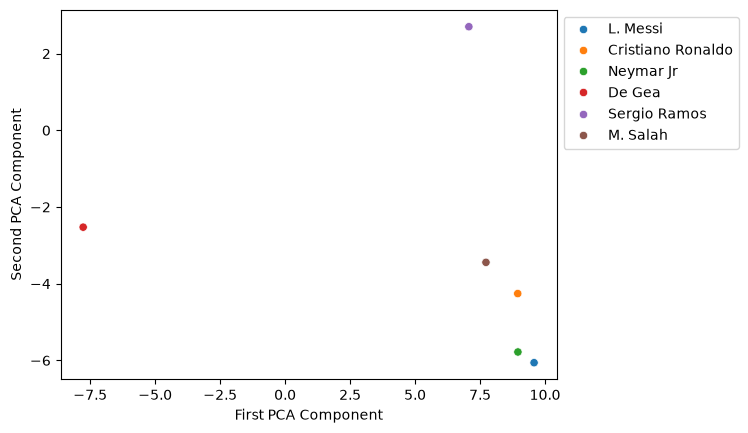

In [37]:
import re
names=["Cristiano Ronaldo","Messi","De Gea","Salah","Sergio Ramos","Neymar"]
player_names=players[players["Name"].str.contains("|".join(names),regex=True,flags=re.IGNORECASE)]["Name"]
player_scores=np.dot(standarized_numerical_data.iloc[player_names.index,:],sorted_eigenvectors[[0,1]].T)
sns.scatterplot(x=player_scores[:,0],y=player_scores[:,1],hue=player_names)
plt.xlabel("First PCA Component")
plt.ylabel("Second PCA Component")
plt.legend(bbox_to_anchor=(1, 1))


Notice Ramos has the highest PC2 component cause he's a defender
De gea is lowest in both since hes a goalkeeper
Ronaldo messi,salah are similar however messi has the best 1st PCA component and Salah has the best 2nd PCA component

<h1 style="height:50px">Manual Python Implementation</h1>

Text(0, 0.5, 'Second PCA Component')

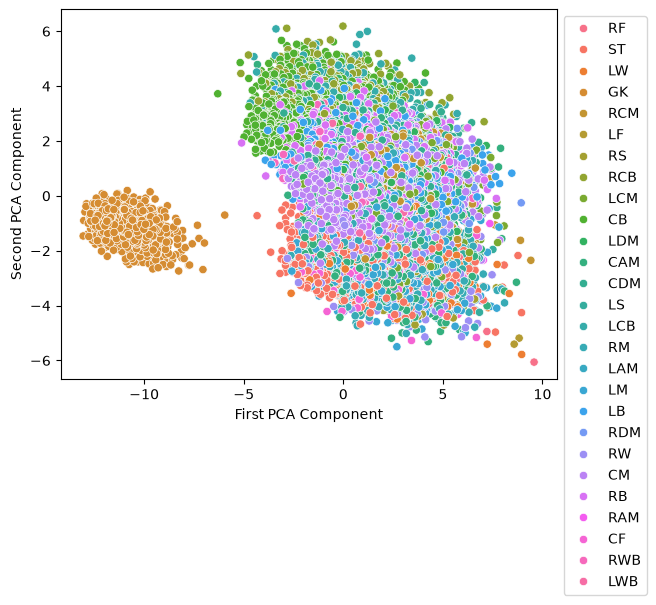

In [38]:
import Matrix_Functions
standarized_numerical_data2=Matrix_Functions.standarize_data(list(numerical_data.values))
covariance_matrix2=Matrix_Functions.covariance(list(standarized_numerical_data2))
eigenvalues2,eigenvectors2=np.linalg.eig(covariance_matrix2)
eigenvalues2=eigenvalues2.real
eigenvectors2=eigenvectors2.real
sorted_eigenvalues_indices2=list(np.argsort(eigenvalues2,descending=True))
sorted_eigenvalues2=np.sort(eigenvalues2,descending=True)
sorted_eigenvectors2=Matrix_Functions.matrix_transpose(list(eigenvectors2))
sorted_eigenvectors3=[]
for idx,value in enumerate(sorted_eigenvalues_indices2):
    sorted_eigenvectors3.append(sorted_eigenvectors2[value])
    if idx==1:
        break
player_scores2=Matrix_Functions.matrix_multiplication(standarized_numerical_data2,Matrix_Functions.matrix_transpose(sorted_eigenvectors3))
x_player_scores=[]
y_player_scores=[]
for i in range(0,len(player_scores2)):
    x_player_scores.append(player_scores2[i][0])
    y_player_scores.append(player_scores2[i][1])
sns.scatterplot(x=x_player_scores,y=y_player_scores,hue=players["Position"])
plt.xlabel("First PCA Component")
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel("Second PCA Component")



Short Note: Using unstandarized matrix gives completely different plot since the variance between variables will be different
(Specifically Values is going to make a big difference since the units are very large numbers (millions,thousands) )

The numpy version takes 1-2 seconds however the manual functions take between 12-15 seconds and that comes to numpy using low level C to communicate directly with memory addresses and CPU instead of Python doing two-three nested for loops which gives a much larger time complexity

<h1 style="height:50px; color:red">Task 2.3</h1>

<h1 style="height:40px;">Euclidean Distance</h1>

In [39]:
import math
Salah=players[players["Name"]=="M. Salah"]
Salah_Data=standarized_numerical_data.iloc[Salah.index].values[0]
Euclidean_Distance_0=((Salah_Data-standarized_numerical_data)**2).values
Euclidean_Distance=[]
for i in Euclidean_Distance_0:
    Euclidean_Distance.append(np.sqrt(np.sum(i)))

Euclidean_Distance_Indices=np.argsort(Euclidean_Distance)
Euclidean_Distance=np.sort(Euclidean_Distance)
Euclidean_Distance=Euclidean_Distance[1:]
Euclidean_Distance_Indices=Euclidean_Distance_Indices[1:] # M Salah himself is the first since the difference will be zero
print(players["Name"].iloc[Euclidean_Distance_Indices].head(5))




25    K. Mbappé
55      L. Sané
32     Coutinho
23    S. Agüero
58      S. Mané
Name: Name, dtype: str


Lets check them in the PCA analysis

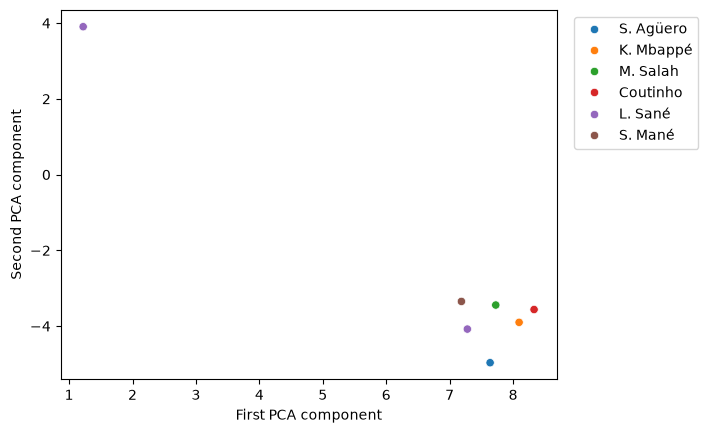

In [40]:
names=["M. Salah","K. Mbappé","L. Sané","Coutinho","S. Agüero","S. Mané"]
indices=players[players["Name"].str.contains("|".join(names),regex=True)]
player_scores=np.dot(standarized_numerical_data.iloc[indices.index],sorted_eigenvectors.T)
sns.scatterplot(x=player_scores[:,0],y=player_scores[:,1],hue=indices["Name"])
plt.xlabel("First PCA component")
plt.ylabel("Second PCA component")
plt.legend(bbox_to_anchor=(1.3,1))

<h1 style="height:40px;">Manhattan Distance</h1>

In [56]:
Manhattan_Distance_0=np.abs(Salah_Data-standarized_numerical_data.values)
Manhattan_Distance=[]
for i in Manhattan_Distance_0:
    Manhattan_Distance.append(np.sum(i))
Manhattan_Distance_Indices=np.argsort(Manhattan_Distance)
Manhattan_Distance=np.sort(Manhattan_Distance)
Manhattan_Distance=Manhattan_Distance[1:]
Manhattan_Distance_Indices=Manhattan_Distance_Indices[1:]
print(players.iloc[Manhattan_Distance_Indices]["Name"].head(5))

25       K. Mbappé
58         S. Mané
55         L. Sané
17    A. Griezmann
23       S. Agüero
Name: Name, dtype: str


Notice the difference in rankings and the player "A.Griezmann" he wasnt there

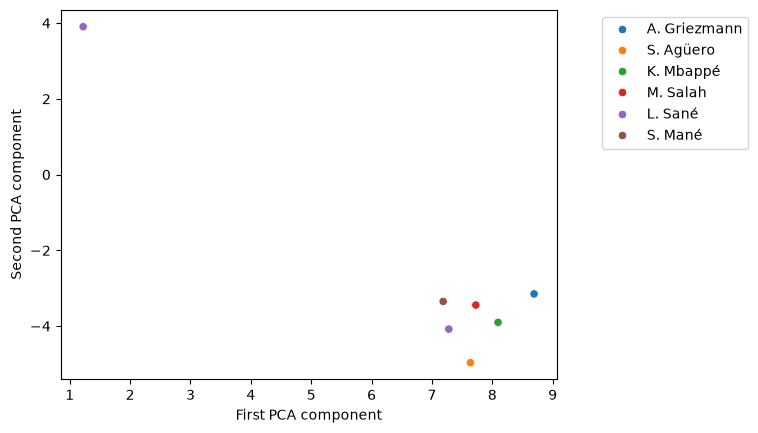

In [50]:
names=["M. Salah","K. Mbappé","L. Sané","A. Griezmann","S. Agüero","S. Mané"]
indices=players[players["Name"].str.contains("|".join(names),regex=True)]
player_scores=np.dot(standarized_numerical_data.iloc[indices.index],sorted_eigenvectors.T)
sns.scatterplot(x=player_scores[:,0],y=player_scores[:,1],hue=indices["Name"])
plt.xlabel("First PCA component")
plt.ylabel("Second PCA component")
plt.legend(bbox_to_anchor=(1.4,1))

<h1 style="height:40px;">Pearson Correlation</h1>

In [44]:
x_sum=np.sum(Salah_Data)
y_sum=np.sum(standarized_numerical_data.values,axis=1)
xy_sum=np.sum(Salah_Data*standarized_numerical_data.values,axis=1)
x2_sum=np.sum(Salah_Data**2)
y2_sum=np.sum(standarized_numerical_data.values**2,axis=1)
n=len(Salah_Data)
Pearson_Correlation=[]
for i in range(0,len(standarized_numerical_data)):
        try:
            Pearson_Correlation.append(
            (n*xy_sum[i]-x_sum*y_sum[i])/math.sqrt( (n*x2_sum-x_sum**2)*(n*y2_sum[i]-y_sum[i]**2)   )
            )
        except ValueError:
            Pearson_Correlation.append(None)
Pearson_Correlation_Indices=np.argsort(np.array(Pearson_Correlation),descending=True)[1:]
Pearson_Correlation=np.sort(np.array(Pearson_Correlation),descending=True)[1:]
print(players.iloc[Pearson_Correlation_Indices]["Name"].head(5))

25    K. Mbappé
5     E. Hazard
0      L. Messi
2     Neymar Jr
58      S. Mané
Name: Name, dtype: str


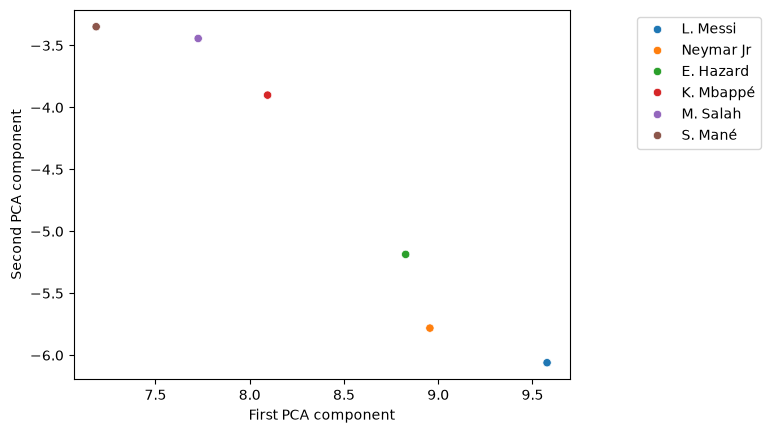

In [55]:
names=["M. Salah","K. Mbappé","S. Mané","L. Messi","E. Hazard","Neymar Jr"]
indices=players[players["Name"].str.contains("|".join(names),regex=True)]
player_scores=np.dot(standarized_numerical_data.iloc[indices.index],sorted_eigenvectors.T)
sns.scatterplot(x=player_scores[:,0],y=player_scores[:,1],hue=indices["Name"])
plt.xlabel("First PCA component")
plt.ylabel("Second PCA component")
plt.legend(bbox_to_anchor=(1.4,1))

Although some players differ however we can say for sure that Mbappe and Mane are similiar to Salah since they appear in the 3 methods
also i'd pick coutinho, aguero and griezmann since they are closer in the manhattan and euclidean distance compared to how messi,neymar and hazard are close to him